In [1]:
import os

base_path = "/kaggle/input/datasets/salader/dogsvscats"

train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

print(train_path)
print(test_path)

/kaggle/input/datasets/salader/dogsvscats/train
/kaggle/input/datasets/salader/dogsvscats/test


In [2]:
import tensorflow as tf 
import keras 
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# for data augmentation
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast,
    RandomTranslation,
    Rescaling,
    Flatten,
    Dense
)
from keras.applications.vgg16 import VGG16

from sklearn.metrics import accuracy_score
import cv2
import os

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import numpy as np

import random

## creating model 

In [4]:
conv_base = VGG16(
    weights='imagenet',
    include_top=False, # this means that you are not importing the FC or ANN layer 
    input_shape=(150,150,3)
)

I0000 00:00:1785647616.640797     544 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
# Freeze the pretrained convolutional base
conv_base.trainable = False

In [6]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [7]:
model = Sequential([
    keras.layers.Input(shape=(150, 150, 3)),
    # Normalize images
    Rescaling(1./255),

    # Data Augmentation (only active during training)
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.2),
    RandomTranslation(0.1, 0.1),

    # Pre-trained CNN
    conv_base,

    # Classifier
    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 150, 150, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
# generators (devides data into batches)
# use full for large impout of data`

In [10]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=train_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150,150)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory=test_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150,150)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


# Training

In [11]:
callback = EarlyStopping(
    monitor='val_loss', # watches validation loss each epoch
    verbose=1,
    patience=3,             
    restore_best_weights=True  # rolls back to the best epoch's weights when it stops
)

In [12]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [13]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds,callbacks=callback)
# there are 625 batches

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.8273 - loss: 0.3810 - val_accuracy: 0.9046 - val_loss: 0.2267
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.8572 - loss: 0.3193 - val_accuracy: 0.9110 - val_loss: 0.2095
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8643 - loss: 0.3081 - val_accuracy: 0.9150 - val_loss: 0.2039
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8677 - loss: 0.2972 - val_accuracy: 0.9146 - val_loss: 0.1997
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8733 - loss: 0.2875 - val_accuracy: 0.9150 - val_loss: 0.2042
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8738 - loss: 0.2851 - val_accuracy: 0.9018 - val_loss: 0.2315
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8775 - loss: 0.2805 - val_accuracy: 0.9156 - val_loss: 0.1995
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8798 - loss: 0.2724 - 

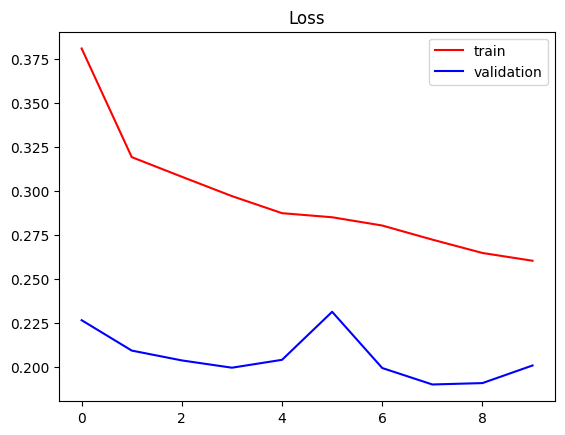

In [14]:
plt.title('Loss')
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

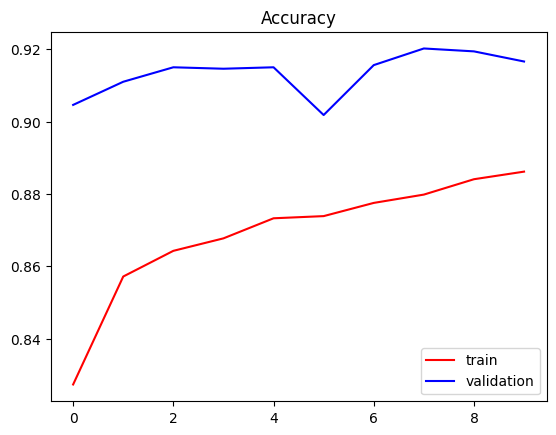

In [15]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [16]:
# ways to reduce overfitting 

# add more data
# data augmentation
# l1/l2 regularilization
# dropout
# Batch Normalization
# reduce model complexity

In [17]:
import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/marquis03/cats-and-dogs'):
    print(dirname,'\n',filenames)
    break

/kaggle/input/datasets/marquis03/cats-and-dogs 
 ['val.csv', 'train.csv']


In [18]:
df = pd.read_csv('/kaggle/input/datasets/marquis03/cats-and-dogs/val.csv')
df.head()

,image:FILE,category
0,val/cat/Persian_13_jpg.rf.dd6ccb81649242fcc8a2...,0
1,val/cat/Birman_137_jpg.rf.dc638a7840b71bfdcc9d...,0
2,val/cat/Siamese_142_jpg.rf.de98806682118bd0281...,0
3,val/cat/Birman_163_jpg.rf.de852821da3d65ebd262...,0
4,val/cat/Bengal_141_jpg.rf.e656908b712d2cb13742...,0


# Testing

In [19]:
import cv2

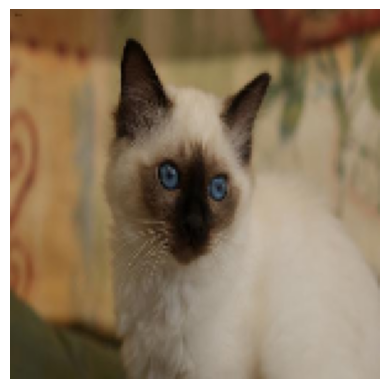

True: cat | Predicted: cat | Raw score: 0.0006


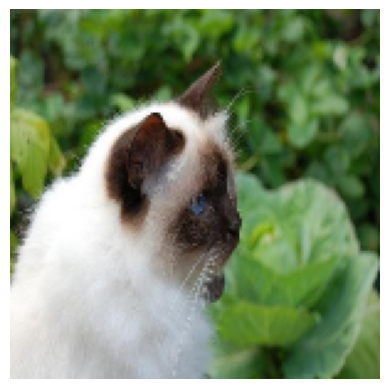

True: cat | Predicted: dog | Raw score: 0.5140


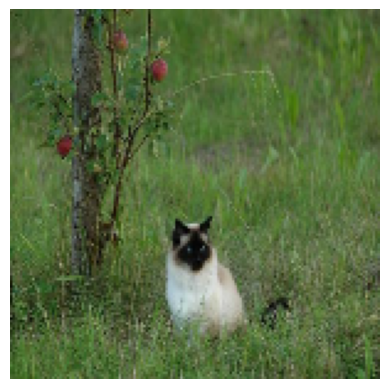

True: cat | Predicted: dog | Raw score: 0.9811


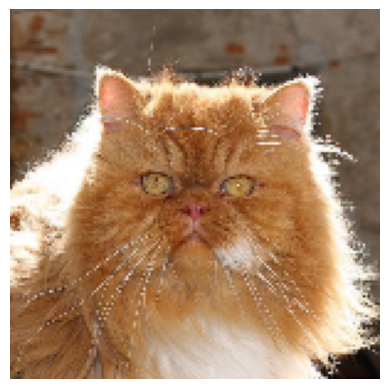

True: cat | Predicted: cat | Raw score: 0.0044


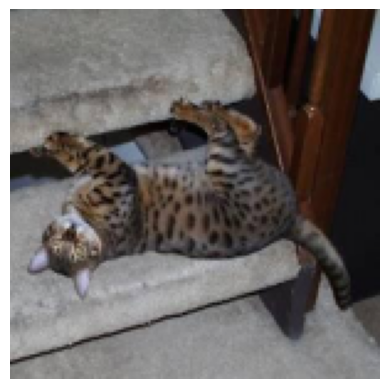

True: cat | Predicted: cat | Raw score: 0.0450


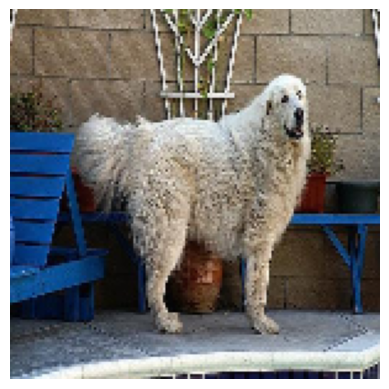

True: dog | Predicted: dog | Raw score: 0.9877


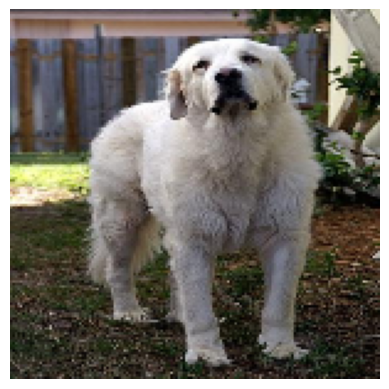

True: dog | Predicted: dog | Raw score: 0.9999


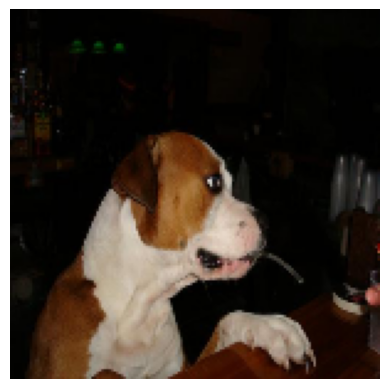

True: dog | Predicted: dog | Raw score: 0.9742


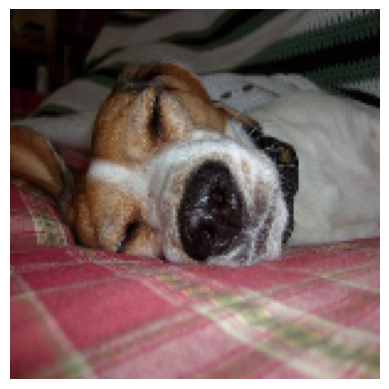

True: dog | Predicted: cat | Raw score: 0.1704


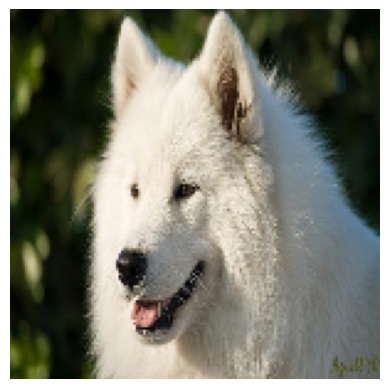

True: dog | Predicted: cat | Raw score: 0.1071


In [20]:
path = "/kaggle/input/datasets/marquis03/cats-and-dogs"

# Pick 5 cats (category == 0) and 5 dogs (category == 1) explicitly
cats_sample = df[df["category"] == 0].sample(5, random_state=None).reset_index(drop=True)
dogs_sample = df[df["category"] == 1].sample(5, random_state=None).reset_index(drop=True)
sample = pd.concat([cats_sample, dogs_sample]).reset_index(drop=True)

for _, row in sample.iterrows():
    image_path = os.path.join(path, row["image:FILE"])
    true_label = "dog" if row["category"] == 1 else "cat"

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (150, 150))

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # NOTE: no manual /255.0 here — the model already has a Rescaling(1./255) layer.
    # Feed it raw pixel values (0-255), just as float32.
    img_input = img.astype("float32")
    img_input = np.expand_dims(img_input, axis=0)

    prediction = model.predict(img_input, verbose=0)
    y_pred = np.where(prediction > 0.5, 1, 0)   # 0.5 is the standard threshold for sigmoid
    pred_label = "dog" if y_pred[0][0] == 1 else "cat"

    print(f"True: {true_label} | Predicted: {pred_label} | Raw score: {prediction[0][0]:.4f}")

In [21]:
train_ds.class_names

['cats', 'dogs']

In [22]:
path = "/kaggle/input/datasets/marquis03/cats-and-dogs"

y_true = []
y_pred = []

for _, row in df.iterrows():
    image_path = os.path.join(path, row["image:FILE"])

    # Read and preprocess image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (150, 150))

    img_input = img.astype("float32")
    img_input = np.expand_dims(img_input, axis=0)

    # Prediction
    pred = model.predict(img_input, verbose=0)[0][0]

    predicted_label = 1 if pred > 0.5 else 0

    # Save labels
    y_true.append(row["category"])
    y_pred.append(predicted_label)

# Overall accuracy
accuracy = accuracy_score(y_true, y_pred)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

Validation Accuracy: 0.8857
Validation Accuracy: 88.57%


<Axes: >

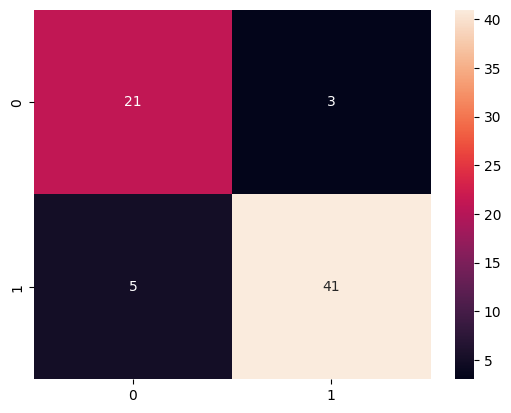

In [25]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_true,y_pred),annot=True)